### Imports, Loading Model & Defining Optimization

In [7]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error
from bayes_opt import BayesianOptimization
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from bayes_opt.logger import JSONLogger
from bayes_opt.event import Events
from bayes_opt.util import load_logs
from skopt.plots import plot_evaluations, plot_objective
from skopt.space import Real, Integer, Space
from skopt.plots import plot_convergence
from skopt import gp_minimize

import re
import os
import joblib

In [11]:
with open("BestModels/WithoutOutliers/RidgeRegression.pkl", "rb") as model:
    lin_model=joblib.load(model)
    
with open("Data/Transformed_OutlierAdjusted/xNormalizer.pkl", "rb") as norm:
    xNormalizer=joblib.load(norm)
    
with open("Data/Transformed_OutlierAdjusted/yScaler.pkl", "rb") as norm:
    yScaler=joblib.load(norm)

In [ ]:
def blackbox(X):
    columns = ["sindex","nuccut", "diffexp","lowindx","lowexp","lowdiffbreak","lowdiffbreaksoft","diffnorm","DE","DR","alvel","highexp","diffbreak","diffbreaksoft","lowbreak","lowsoft","spiralwidth"]
    df_X=pd.DataFrame(X).T
    df_X.columns = columns
    y = lin_model.predict(df_X)
    # print(y)
    y = yScaler.inverse_transform(y)
    # print(y)
    try:
        y = np.exp(y)
    except ValueError:
        y = sys.float_info.max
    finally:
        y=np.sum(y)
        if(y>1000): y=1000
    # print(y)
    return np.sum(y)   

### Parameter Opt (100/150)

In [33]:
n_jobs = os.cpu_count()-1
res = gp_minimize(blackbox,
                #   dimensions=grid_params,
                  dimensions = [(0.0, 1.0)]*17,
                  acq_func="EI",
                  n_calls = 250,
                  n_random_starts=100,
                  noise = 0,
                  random_state = 42,
                  n_jobs = n_jobs
                  )

print(f"Minimum: {res.fun:.2f}, At: {res.x}")

# Runtime for 250 calls (100 random) = 30mins

Minimum: 0.00, At: [0.2591383206363089, 0.13667728056830225, 0.54398622589762, 0.888319016305061, 0.6209711235185301, 0.6897635264690732, 0.9373665636725282, 0.11123253407886811, 0.0, 0.32383257418492545, 0.44922219549028836, 0.0, 0.054332545903828244, 0.1827142169988695, 1.0, 0.3168858423569365, 1.0]


#### Visualize

Minimum: 0.0000000000, At: [0.2591383206363089, 0.13667728056830225, 0.54398622589762, 0.888319016305061, 0.6209711235185301, 0.6897635264690732, 0.9373665636725282, 0.11123253407886811, 0.0, 0.32383257418492545, 0.44922219549028836, 0.0, 0.054332545903828244, 0.1827142169988695, 1.0, 0.3168858423569365, 1.0]


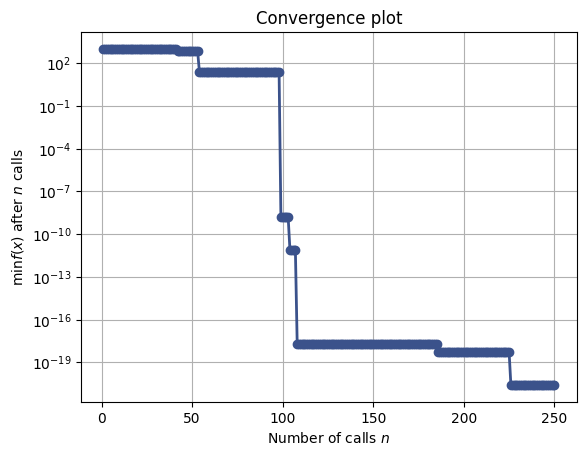

In [54]:
plot_convergence(res,
                 yscale = "log"
                 )
print(f"Minimum: {res.fun:.10f}, At: {res.x}")

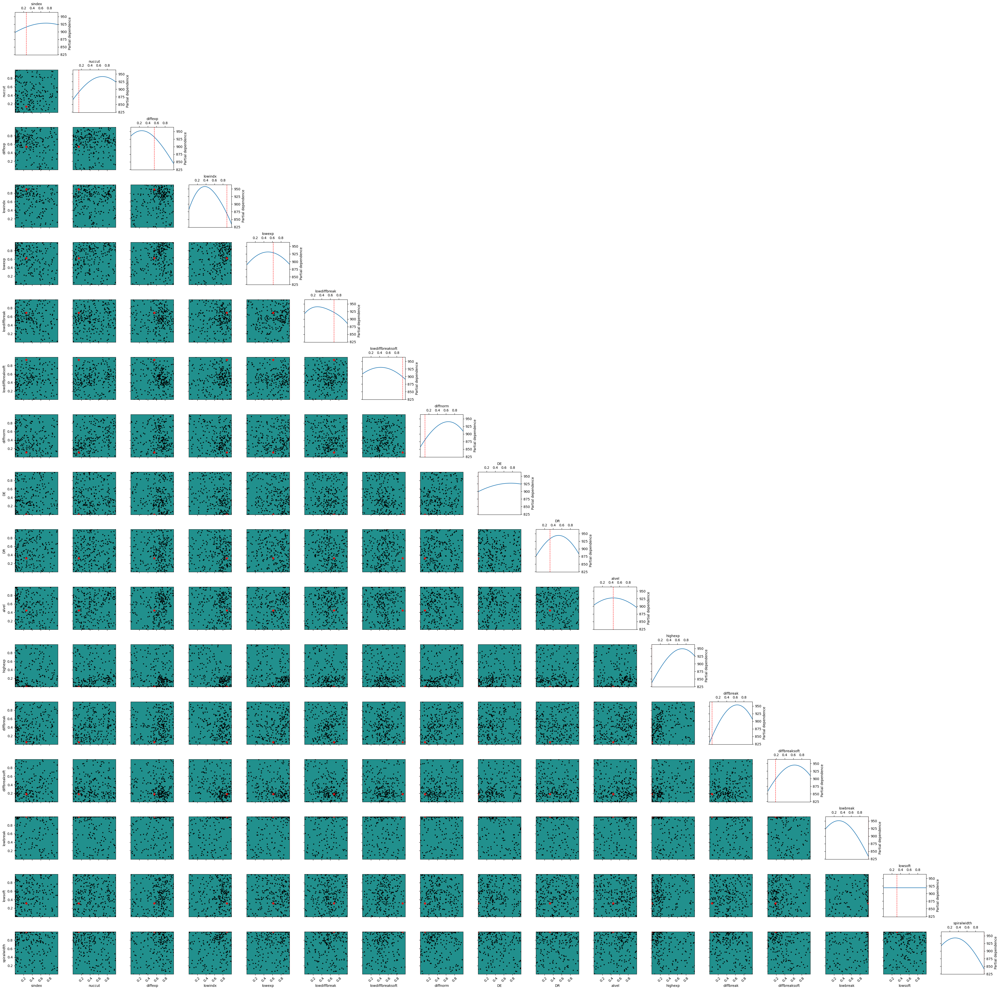

In [43]:
columns = ["sindex","nuccut", "diffexp","lowindx","lowexp","lowdiffbreak","lowdiffbreaksoft","diffnorm","DE","DR","alvel","highexp","diffbreak","diffbreaksoft","lowbreak","lowsoft","spiralwidth"]
_ = plot_objective(res,
                   levels = 10,
                   n_points = 100, #number of points at which to evaluate partial dependence
                   n_samples = 250, #number of points sampled for plot
                   dimensions = columns,
                   size = 3,
                   zscale = "log"
                   )

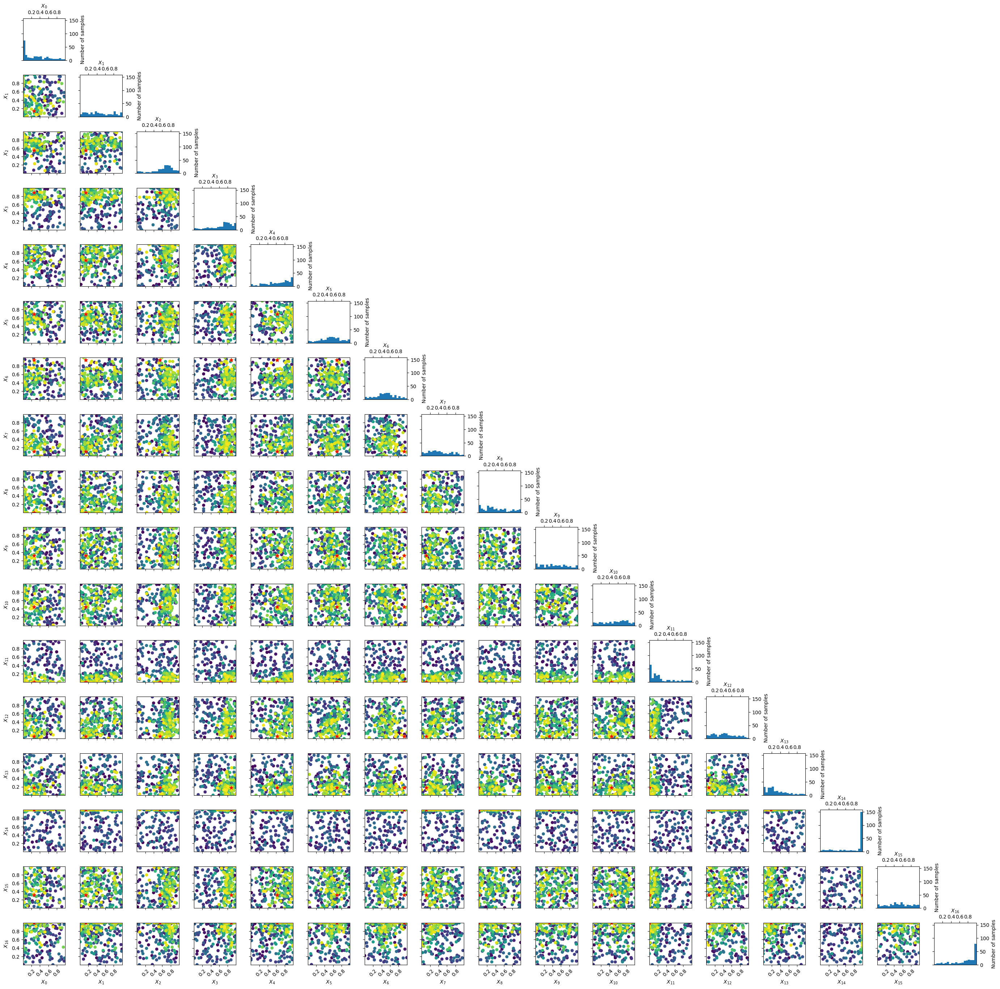

In [40]:
_ = plot_evaluations(res, 
                     bins = 20,
                     dimensions = columns
                     )

### Parameter Opt (10000/0)

In [45]:
n_jobs = os.cpu_count()-1
res2 = gp_minimize(blackbox,
                #   dimensions=grid_params,
                  dimensions = [(0.0, 1.0)]*17,
                  acq_func="EI",
                  n_calls = 1000,
                  n_random_starts=1000,
                  noise = 0,
                  random_state = 42,
                  n_jobs = n_jobs
                  )

print(f"Minimum: {res2.fun:.5f}, At: {res2.x}")

# Runtime for 1000 random calls  = 3mins

Minimum: 0.00, At: [0.5011529991820098, 0.39717877742921115, 0.5397326187599429, 0.6279500527726359, 0.6743038064090485, 0.5324811925594263, 0.7214220673287318, 0.14127804927550583, 0.21198249090223859, 0.8187350040742704, 0.32252797784641524, 0.02289382497612025, 0.15379114966803112, 0.2236144344963113, 0.9573228878945874, 0.5730414289308494, 0.932730740476255]


#### Visualize

Minimum: 0.0000000000, At: [0.2591383206363089, 0.13667728056830225, 0.54398622589762, 0.888319016305061, 0.6209711235185301, 0.6897635264690732, 0.9373665636725282, 0.11123253407886811, 0.0, 0.32383257418492545, 0.44922219549028836, 0.0, 0.054332545903828244, 0.1827142169988695, 1.0, 0.3168858423569365, 1.0]


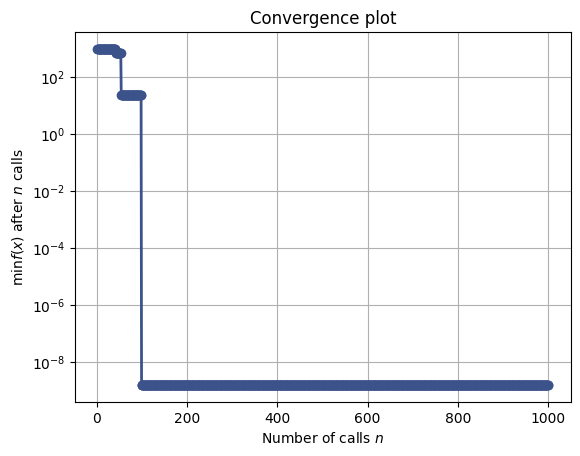

In [46]:
plot_convergence(res2,
                 yscale = "log"
                 )
print(f"Minimum: {res.fun:.10f}, At: {res.x}")

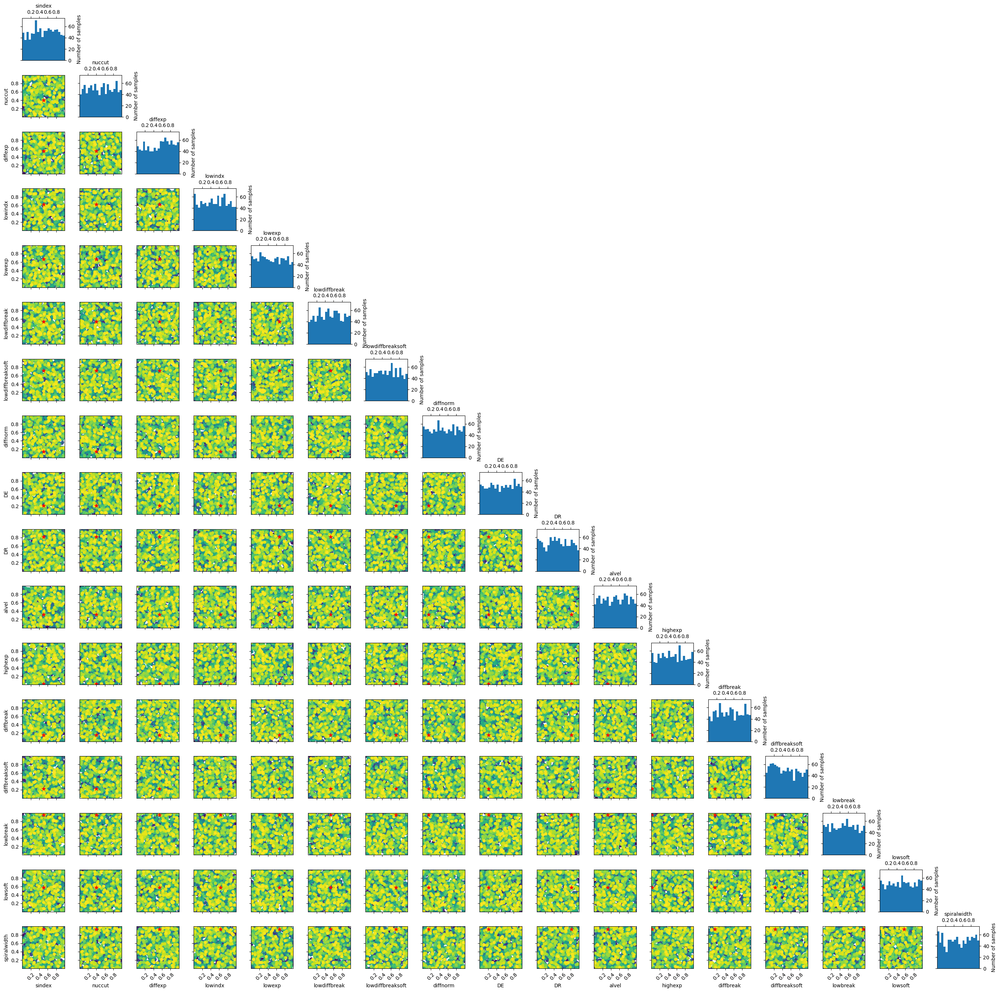

In [48]:
_ = plot_evaluations(res2, bins = 20, dimensions = columns)

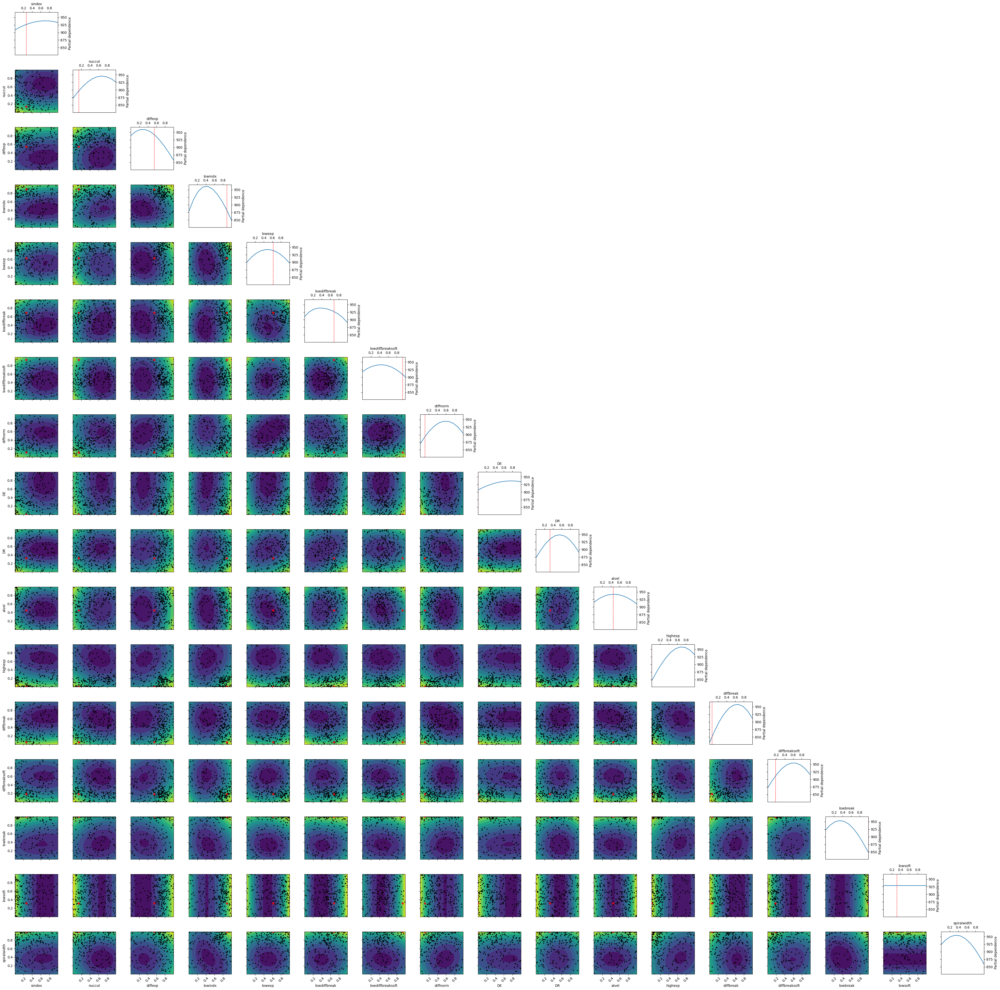

In [53]:
columns = ["sindex","nuccut", "diffexp","lowindx","lowexp","lowdiffbreak","lowdiffbreaksoft","diffnorm","DE","DR","alvel","highexp","diffbreak","diffbreaksoft","lowbreak","lowsoft","spiralwidth"]
_ = plot_objective(res,
                   levels = 10,
                   n_points = 10, #number of points at which to evaluate partial dependence
                   n_samples = 100, #number of points sampled for plot
                   dimensions = columns,
                   size = 3,
                #    zscale = "log",
                   sample_source = "random"
                   )

### Optimum Parameter Search (First Trial)

In [35]:
# def getLoggerPath(dir, base, extension):
#     files = os.listdir(dir)
#     pattern = re.compile(rf"{re.escape(base)}(\d+){re.escape(extension)}")
#     numbers = []
#     for file in files:
#         match = pattern.match(file)
#         if match: numbers.append(int(match.group(1)))
#     if numbers: next_number=max(numbers)+1
#     else: next_number=0
    
#     new_filename=f"{base}{next_number}{extension}"
#     return os.path.join(dir, new_filename)
    
# def getLoggedFiles(directory):
#     paths = []
#     for root, dirs, files in os.walk(directory):
#         for file in files:
#             file_path = os.path.join(root,file)
#             paths.append(file_path)
#     return paths
   
# def blackbox(X):
#     # X = [[sindex, nuccut, diffexp, lowindx, lowexp, lowdiffbreak,
#     #       lowdiffbreaksoft, diffnorm, DE, DR, alvel, highexp, diffbreak,
#     #       diffbreaksoft, lowbreak, lowsoft, spiralwidth]]
#     columns = ["sindex","nuccut", "diffexp","lowindx","lowexp","lowdiffbreak","lowdiffbreaksoft","diffnorm","DE","DR","alvel","highexp","diffbreak","diffbreaksoft","lowbreak","lowsoft","spiralwidth"]
#     df_X=pd.DataFrame(X, columns=columns)
#     return -np.sum(lin_model.predict(df_X))         
    

In [30]:
# grid_params = {
#     "sindex": (0.,1.),
#     "nuccut": (0.,1.),
#     "diffexp": (0.,1.),
#     "lowindx": (0.,1.),
#     "lowexp": (0.,1.),
#     "lowdiffbreak": (0.,1.),
#     "lowdiffbreaksoft": (0.,1.),
#     "diffnorm": (0.,1.),
#     "DE": (0.,1.),
#     "DR": (0.,1.),
#     "alvel": (0.,1.),
#     "highexp": (0.,1.),
#     "diffbreak": (0.,1.),
#     "diffbreaksoft": (0.,1.),
#     "lowbreak": (0.,1.),
#     "lowsoft": (0.,1.),
#     "spiralwidth": (0.,1.)
# }

# n_init_points = 0
# n_iter=200
# n_cpus = os.cpu_count()-1

# optimizer = BayesianOptimization(
#     f=blackbox,
#     pbounds = grid_params,
#     random_state=42
# )
# load_logs(optimizer, logs=getLoggedFiles("./OptLogs"))
# logger = JSONLogger(path=getLoggerPath("./OptLogs", "opt.log_", ".json"))
# optimizer.subscribe(Events.OPTIMIZATION_STEP, logger)

# optimizer.maximize(
#     init_points = n_init_points,
#     n_iter = n_iter
# )

In [53]:
# class Res:
#     def __init__(self):
#         fun = 0.5,
#         x = [0, 0],
#         func_vals = [0.5, 1],
#         x_iters = [[0, 0], [0, 1]],
#         space = Space([(0.,1.), (0., 1.)])
# results = Res()
# from scipy.optimize import OptimizeResult
# from sklearn import LinearRegression
# model = LinearRegression()

# results = {
#     "fun": 0.5,
#     "x": [0, 0],
#     "func_vals": [0.5, 1],
#     "x_iters": [[0, 0], [0, 1]],
#     "space": Space([(0.,1.), (0., 1.)]),
#     "models": lin_model
# }
# result = OptimizeResult(results)
# print(result)
# _ = plot_objective(result)

In [51]:
# grid_params = {
#     "sindex": Real(0.,1., prior="uniform"),
#     "nuccut": Real(0.,1., prior="uniform"),
#     "diffexp": Real(0.,1., prior="uniform"),
#     "lowindex": Real(0.,1., prior="uniform"),
#     "lowexp": Real(0.,1., prior="uniform"),
#     "lowdiffbreak": Real(0.,1., prior="uniform"),
#     "lowdiffbreaksoft": Real(0.,1., prior="uniform"),
#     "diffnorm": Real(0.,1., prior="uniform"),
#     "DE": Real(0.,1., prior="uniform"),
#     "DR": Real(0.,1., prior="uniform"),
#     "alvel": Real(0.,1., prior="uniform"),
#     "highexp": Real(0.,1., prior="uniform"),
#     "diffbreak": Real(0.,1., prior="uniform"),
#     "diffbreaksoft": Real(0.,1., prior="uniform"),
#     "lowbreak": Real(0.,1., prior="uniform"),
#     "lowsoft": Real(0.,1., prior="uniform"),
#     "spiralwidth": Real(0.,1., prior="uniform")
# }


# gs = BayesSearchCV(
#             estimator = linear_model,
#             search_spaces = grid_params,
#             n_jobs = n_cpus,
#             n_iter = n_iter,
#             scoring = "neg_mean_squared_error",
#             verbose = 0
#         )

In [52]:
# X = [[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]]
# print(-np.sum(np.abs(lin_model.predict(X))))